# Treinamento e Avaliação de Modelo LSTM
Este notebook cria um fluxo completo para treinar e avaliar um modelo LSTM em séries temporais de produção/exportação de carnes brasileiras.
Usaremos as métricas: MSE, RMSE e R².

In [2]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Carregar dados
PATH = "/content/carne-brasileira-exportada.csv"
df = pd.read_csv(PATH)
df.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
4,2014,1,suino,37.93,8.686,0.747,0.260,2.34,22.57,62.01,2.811


In [3]:
# Pré-processamento básico
# Usamos dados ordenados por data para cada tipo de carne, gerando uma série temporal consistente.
feature_column = "preco_medio_ton_usd"  # alvo da previsão
meat_types = sorted(df["tipo_carne"].dropna().unique().tolist())

def prepare_meat_data(df, meat_type, feature_column="preco_medio_ton_usd"):
    filtered = df[df["tipo_carne"] == meat_type].copy()
    filtered["date"] = pd.to_datetime(filtered["ano"].astype(str) + "Q" + filtered["trimestre"].astype(str))
    filtered = filtered.sort_values("date").reset_index(drop=True)

    print(f"Tipo de carne: {meat_type} | registros: {len(filtered)}")
    print(filtered[["date", feature_column]].head())

    series = filtered[[feature_column]].astype(float)
    scaler = MinMaxScaler(feature_range=(0, 1))
    series_scaled = scaler.fit_transform(series)

    train_size = int(len(series_scaled) * 0.8)
    train_data = series_scaled[:train_size]
    test_data = series_scaled[train_size:]

    return {
        "filtered": filtered,
        "scaler": scaler,
        "series_scaled": series_scaled,
        "train_data": train_data,
        "test_data": test_data,
        "train_size": train_size,
    }

print("Tipos de carne para previsão:", meat_types)


Tipos de carne para previsão: ['bovino', 'frango', 'suino']


In [4]:
# Função utilitária para criar sequências de time series

def create_sequences(data, seq_len):
    x, y = [], []
    for i in range(len(data) - seq_len):
        x.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(x), np.array(y)

sequence_length = 4  # usando 4 trimestres para prever o próximo trimestre

Trial 6 Complete [00h 00m 11s]
val_loss: 0.004896312020719051

Best val_loss So Far: 0.0046298084780573845
Total elapsed time: 00h 01m 02s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,513 (87.94 KB)

 Trainable params: 22,513 (87.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0190 - mse: 0.0190 - val_loss: 0.0053 - val_mse: 0.0053
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0162 - mse: 0.0162 - val_loss: 0.0063 - val_mse: 0.0063
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0150 - mse: 0.0150 - val_loss: 0.0077 - val_mse: 0.0077
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0154 - mse: 0.0154 - val_loss: 0.0089 - val_mse: 0.0089
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0162 - mse: 0.0162 - val_loss: 0.0099 - val_mse: 0.0099
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0143 - mse: 0.0143 - val_loss: 0.0103 - val_mse: 0.0103
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0168 - mse: 0.0168 - val_loss: 0.0104 - val_mse: 0.0104
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0161 - mse: 0.0161 - val_loss: 0.0102 - val_mse: 0.0102
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0158 - mse: 0.0158 - 

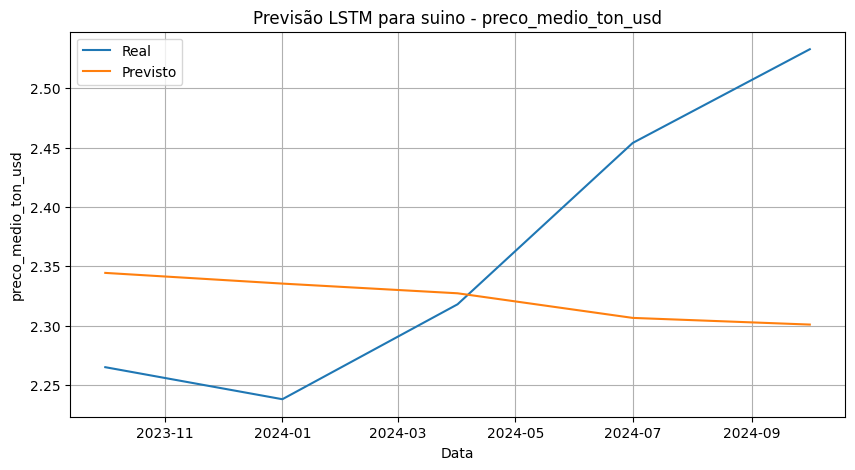

,meat_type,mse,rmse,r2,samples
0,bovino,0.058752,0.242387,-2.710805,44
1,frango,0.031114,0.176391,-2.905323,44
2,suino,0.018302,0.135284,-0.420379,44


In [5]:
# Definir o modelo LSTM e executar o pipeline para cada tipo de carne

def build_lstm_model(hp):
    model = Sequential()
    model.add(
        LSTM(
            hp.Int("units_1", min_value=32, max_value=128, step=32),
            activation="tanh",
            input_shape=(sequence_length, 1),
            return_sequences=True,
        )
    )
    model.add(Dropout(hp.Choice("dropout_1", [0.1, 0.2, 0.3])))
    model.add(
        LSTM(
            hp.Int("units_2", min_value=16, max_value=64, step=16),
            activation="tanh",
        )
    )
    model.add(Dropout(hp.Choice("dropout_2", [0.1, 0.2, 0.3])))
    model.add(
        Dense(
            hp.Int("dense_units", min_value=8, max_value=32, step=8),
            activation="relu",
        )
    )
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mse"],
    )
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

results = []

def train_and_evaluate_meat_type(meat_type):
    data = prepare_meat_data(df, meat_type, feature_column)
    train_data = data["train_data"]
    test_data = data["test_data"]
    filtered = data["filtered"]
    scaler = data["scaler"]
    train_size = data["train_size"]

    x_train, y_train = create_sequences(train_data, sequence_length)
    x_test, y_test = create_sequences(test_data, sequence_length)

    if len(x_train) == 0 or len(x_test) == 0:
        print(f"Dados insuficientes para {meat_type}. Pulando.")
        return None

    tuner = kt.RandomSearch(
        build_lstm_model,
        objective="val_loss",
        max_trials=6,
        executions_per_trial=1,
        directory="kt_dir",
        project_name=f"lstm_tuning_{meat_type}",
    )

    tuner.search(
        x_train,
        y_train,
        epochs=50,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1,
    )

    model = tuner.get_best_models(num_models=1)[0]
    model.summary()

    history = model.fit(
        x_train,
        y_train,
        epochs=30,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1,
    )

    predictions_scaled = model.predict(x_test)
    predictions = scaler.inverse_transform(predictions_scaled)
    actuals = scaler.inverse_transform(y_test)

    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals, predictions)

    print(f"\nResultados para {meat_type}:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

    plt.figure(figsize=(10, 5))
    plt.plot(filtered["date"].iloc[train_size + sequence_length:].reset_index(drop=True), actuals.flatten(), label="Real")
    plt.plot(filtered["date"].iloc[train_size + sequence_length:].reset_index(drop=True), predictions.flatten(), label="Previsto")
    plt.title(f"Previsão LSTM para {meat_type} - {feature_column}")
    plt.xlabel("Data")
    plt.ylabel(feature_column)
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "meat_type": meat_type,
        "mse": mse,
        "rmse": rmse,
        "r2": r2,
        "samples": len(train_data) + len(test_data),
    }

for meat_type in meat_types:
    result = train_and_evaluate_meat_type(meat_type)
    if result:
        results.append(result)

results_df = pd.DataFrame(results)
results_df

In [6]:
# Resumo dos resultados por tipo de carne
results_df

,meat_type,mse,rmse,r2,samples
0,bovino,0.058752,0.242387,-2.710805,44
1,frango,0.031114,0.176391,-2.905323,44
2,suino,0.018302,0.135284,-0.420379,44
